In [1]:
from pyspark.sql import SparkSession

spark = SparkSession.builder \
    .master("local[*]") \
    .appName('test') \
    .getOrCreate()

print(f"Spark version: {spark.version}")

df = spark.range(10)
df.show()

Spark version: 4.1.1
+---+
| id|
+---+
|  0|
|  1|
|  2|
|  3|
|  4|
|  5|
|  6|
|  7|
|  8|
|  9|
+---+



In [2]:
import requests
from pathlib import Path

base_url = "https://raw.githubusercontent.com/databricks/Spark-The-Definitive-Guide/master/data/flight-data/csv/"

years = range(2010, 2016)

data_dir = Path("Data")
data_dir.mkdir(parents=True, exist_ok=True)

for year in years:
    url = f"{base_url}{year}-summary.csv"
    file_path = data_dir / f"{year}-summary.csv"

    print(f"Downloading {url}")

    response = requests.get(url)
    response.raise_for_status()

    with open(file_path, "wb") as f:
        f.write(response.content)

    print(f"Saved to {file_path}")

Saved to Data\2010-summary.csv
Saved to Data\2011-summary.csv
Saved to Data\2012-summary.csv
Saved to Data\2013-summary.csv
Saved to Data\2014-summary.csv
Saved to Data\2015-summary.csv


In [4]:
from pyspark.sql import SparkSession

spark = SparkSession.builder \
    .master("local[*]") \
    .appName('test') \
    .getOrCreate()

print(f"Spark version: {spark.version}")

Spark version: 4.1.1


### Mastering Spark: SPARK THE DEFINITIVE GUIDE

In [5]:
flightData2015 = spark.read.option("inferSchema", "true") \
                .option("header", "true").csv("Data/2015-summary.csv")

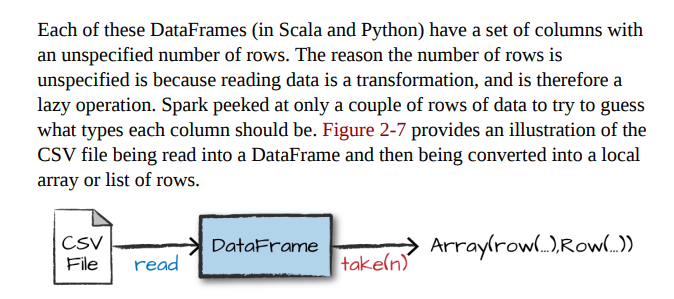

In [6]:
flightData2015.take(3)

[Row(DEST_COUNTRY_NAME='United States', ORIGIN_COUNTRY_NAME='Romania', count=15),
 Row(DEST_COUNTRY_NAME='United States', ORIGIN_COUNTRY_NAME='Croatia', count=1),
 Row(DEST_COUNTRY_NAME='United States', ORIGIN_COUNTRY_NAME='Ireland', count=344)]

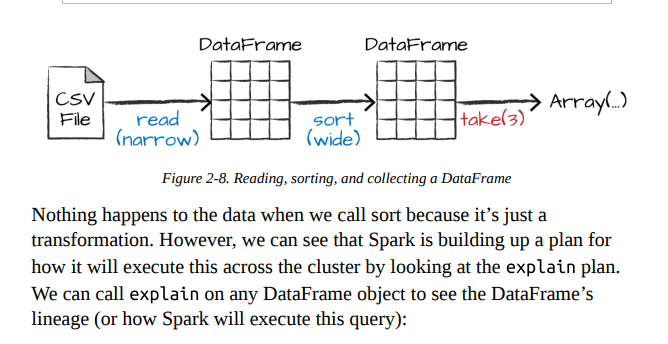

In [7]:
flightData2015.sort("count").explain()

== Physical Plan ==
AdaptiveSparkPlan isFinalPlan=false
+- Sort [count#19 ASC NULLS FIRST], true, 0
   +- Exchange rangepartitioning(count#19 ASC NULLS FIRST, 200), ENSURE_REQUIREMENTS, [plan_id=33]
      +- FileScan csv [DEST_COUNTRY_NAME#17,ORIGIN_COUNTRY_NAME#18,count#19] Batched: false, DataFilters: [], Format: CSV, Location: InMemoryFileIndex(1 paths)[file:/c:/Users/user/Documents/data-engineering-bootcampV2/spark/Data/2..., PartitionFilters: [], PushedFilters: [], ReadSchema: struct<DEST_COUNTRY_NAME:string,ORIGIN_COUNTRY_NAME:string,count:int>




Now, just like we did before, we can specify an action to kick off this plan.
However, before doing that, we’re going to set a configuration. By default,
when we perform a shuffle, Spark outputs 200 shuffle partitions. Let’s set
this value to 5 to reduce the number of the output partitions from the
shuffle:

In [8]:
spark.conf.set("spark.sql.shuffle.partitions", 5)

In [9]:
flightData2015.sort("count").take(2)

[Row(DEST_COUNTRY_NAME='United States', ORIGIN_COUNTRY_NAME='Singapore', count=1),
 Row(DEST_COUNTRY_NAME='Moldova', ORIGIN_COUNTRY_NAME='United States', count=1)]

In [12]:
spark.conf.set("spark.sql.shuffle.partitions", 5)

In [13]:
flightData2015 = spark.read.option("inferSchema", "true") \
                .option("header", "true").csv("Data/2015-summary.csv")

In [14]:
flightData2015.sort("count").explain()

== Physical Plan ==
AdaptiveSparkPlan isFinalPlan=false
+- Sort [count#46 ASC NULLS FIRST], true, 0
   +- Exchange rangepartitioning(count#46 ASC NULLS FIRST, 5), ENSURE_REQUIREMENTS, [plan_id=88]
      +- FileScan csv [DEST_COUNTRY_NAME#44,ORIGIN_COUNTRY_NAME#45,count#46] Batched: false, DataFilters: [], Format: CSV, Location: InMemoryFileIndex(1 paths)[file:/c:/Users/user/Documents/data-engineering-bootcampV2/spark/Data/2..., PartitionFilters: [], PushedFilters: [], ReadSchema: struct<DEST_COUNTRY_NAME:string,ORIGIN_COUNTRY_NAME:string,count:int>




In [15]:
flightData2015.sort("count").show()

+--------------------+-------------------+-----+
|   DEST_COUNTRY_NAME|ORIGIN_COUNTRY_NAME|count|
+--------------------+-------------------+-----+
|       United States|            Estonia|    1|
|              Kosovo|      United States|    1|
|              Zambia|      United States|    1|
|       United States|   Papua New Guinea|    1|
|               Malta|      United States|    1|
|       United States|          Gibraltar|    1|
|            Suriname|      United States|    1|
|       United States|            Croatia|    1|
|            Djibouti|      United States|    1|
|        Burkina Faso|      United States|    1|
|Saint Vincent and...|      United States|    1|
|       United States|             Cyprus|    1|
|       United States|          Singapore|    1|
|             Moldova|      United States|    1|
|              Cyprus|      United States|    1|
|       United States|          Lithuania|    1|
|       United States|           Bulgaria|    1|
|       United State

In [22]:
from pyspark.sql import functions as F

In [24]:
flightData2015.createOrReplaceTempView("flight_data_2015")

In [25]:
# in Python
sqlWay = spark.sql("""
SELECT DEST_COUNTRY_NAME, count(1)
FROM flight_data_2015
GROUP BY DEST_COUNTRY_NAME
""")
dataFrameWay = flightData2015\
.groupBy("DEST_COUNTRY_NAME")\
.count()
sqlWay.explain()
dataFrameWay.explain()

== Physical Plan ==
AdaptiveSparkPlan isFinalPlan=false
+- HashAggregate(keys=[DEST_COUNTRY_NAME#44], functions=[count(1)])
   +- Exchange hashpartitioning(DEST_COUNTRY_NAME#44, 5), ENSURE_REQUIREMENTS, [plan_id=123]
      +- HashAggregate(keys=[DEST_COUNTRY_NAME#44], functions=[partial_count(1)])
         +- FileScan csv [DEST_COUNTRY_NAME#44] Batched: false, DataFilters: [], Format: CSV, Location: InMemoryFileIndex(1 paths)[file:/c:/Users/user/Documents/data-engineering-bootcampV2/spark/Data/2..., PartitionFilters: [], PushedFilters: [], ReadSchema: struct<DEST_COUNTRY_NAME:string>


== Physical Plan ==
AdaptiveSparkPlan isFinalPlan=false
+- HashAggregate(keys=[DEST_COUNTRY_NAME#44], functions=[count(1)])
   +- Exchange hashpartitioning(DEST_COUNTRY_NAME#44, 5), ENSURE_REQUIREMENTS, [plan_id=136]
      +- HashAggregate(keys=[DEST_COUNTRY_NAME#44], functions=[partial_count(1)])
         +- FileScan csv [DEST_COUNTRY_NAME#44] Batched: false, DataFilters: [], Format: CSV, Location: InMe

In [26]:
# in Python
maxSql = spark.sql("""
SELECT DEST_COUNTRY_NAME, sum(count) as destination_total
FROM flight_data_2015
GROUP BY DEST_COUNTRY_NAME
ORDER BY sum(count) DESC
LIMIT 5
""")
maxSql.show()

+-----------------+-----------------+
|DEST_COUNTRY_NAME|destination_total|
+-----------------+-----------------+
|    United States|           411352|
|           Canada|             8399|
|           Mexico|             7140|
|   United Kingdom|             2025|
|            Japan|             1548|
+-----------------+-----------------+



In [27]:
flightData2015\
.groupBy("DEST_COUNTRY_NAME")\
.sum("count")\
.withColumnRenamed("sum(count)", "destination_total")\
.sort(F.desc("destination_total"))\
.limit(5)\
.show()

+-----------------+-----------------+
|DEST_COUNTRY_NAME|destination_total|
+-----------------+-----------------+
|    United States|           411352|
|           Canada|             8399|
|           Mexico|             7140|
|   United Kingdom|             2025|
|            Japan|             1548|
+-----------------+-----------------+



In [28]:
flightData2015\
.groupBy("DEST_COUNTRY_NAME")\
.sum("count")\
.withColumnRenamed("sum(count)", "destination_total")\
.sort(F.desc("destination_total"))\
.limit(5)\
.explain()

== Physical Plan ==
AdaptiveSparkPlan isFinalPlan=false
+- TakeOrderedAndProject(limit=5, orderBy=[destination_total#115L DESC NULLS LAST], output=[DEST_COUNTRY_NAME#44,destination_total#115L])
   +- HashAggregate(keys=[DEST_COUNTRY_NAME#44], functions=[sum(count#46)])
      +- Exchange hashpartitioning(DEST_COUNTRY_NAME#44, 5), ENSURE_REQUIREMENTS, [plan_id=244]
         +- HashAggregate(keys=[DEST_COUNTRY_NAME#44], functions=[partial_sum(count#46)])
            +- FileScan csv [DEST_COUNTRY_NAME#44,count#46] Batched: false, DataFilters: [], Format: CSV, Location: InMemoryFileIndex(1 paths)[file:/c:/Users/user/Documents/data-engineering-bootcampV2/spark/Data/2..., PartitionFilters: [], PushedFilters: [], ReadSchema: struct<DEST_COUNTRY_NAME:string,count:int>




In [1]:
from pyspark.sql import SparkSession

spark = SparkSession.builder \
    .master("local[*]") \
    .appName('test') \
    .getOrCreate()

print(f"Spark version: {spark.version}")

Spark version: 4.1.1


In [2]:
staticDataFrame = spark.read.format("csv")\
                    .option("header", "true")\
                    .option("inferSchema", "true")\
                    .load("Data/definitive_guide_spark/by_day/*.csv")

staticDataFrame.createOrReplaceTempView("retail_data")
staticSchema = staticDataFrame.schema
staticSchema

StructType([StructField('InvoiceNo', StringType(), True), StructField('StockCode', StringType(), True), StructField('Description', StringType(), True), StructField('Quantity', IntegerType(), True), StructField('InvoiceDate', TimestampType(), True), StructField('UnitPrice', DoubleType(), True), StructField('CustomerID', DoubleType(), True), StructField('Country', StringType(), True)])

In [3]:
staticDataFrame.show(5)

+---------+---------+--------------------+--------+-------------------+---------+----------+--------------+
|InvoiceNo|StockCode|         Description|Quantity|        InvoiceDate|UnitPrice|CustomerID|       Country|
+---------+---------+--------------------+--------+-------------------+---------+----------+--------------+
|   580538|    23084|  RABBIT NIGHT LIGHT|      48|2011-12-05 08:38:00|     1.79|   14075.0|United Kingdom|
|   580538|    23077| DOUGHNUT LIP GLOSS |      20|2011-12-05 08:38:00|     1.25|   14075.0|United Kingdom|
|   580538|    22906|12 MESSAGE CARDS ...|      24|2011-12-05 08:38:00|     1.65|   14075.0|United Kingdom|
|   580538|    21914|BLUE HARMONICA IN...|      24|2011-12-05 08:38:00|     1.25|   14075.0|United Kingdom|
|   580538|    22467|   GUMBALL COAT RACK|       6|2011-12-05 08:38:00|     2.55|   14075.0|United Kingdom|
+---------+---------+--------------------+--------+-------------------+---------+----------+--------------+
only showing top 5 rows


In [4]:
staticDataFrame.count()

541909

In [5]:
from pyspark.sql.functions import window, column, desc, col

staticDataFrame \
    .selectExpr(
        "CustomerId",
        "(UnitPrice * Quantity) as total_cost",
        "InvoiceDate"
    ) \
    .groupBy(
        column("CustomerId"),
        window(col("InvoiceDate"), "1 day")
    ) \
    .sum("total_cost") \
    .orderBy(desc("sum(total_cost)")) \
    .show(5)

+----------+--------------------+------------------+
|CustomerId|              window|   sum(total_cost)|
+----------+--------------------+------------------+
|   17450.0|{2011-09-20 01:00...|          71601.44|
|      NULL|{2011-11-14 01:00...|          55316.08|
|      NULL|{2011-11-07 01:00...|          42939.17|
|      NULL|{2011-03-29 01:00...| 33521.39999999998|
|      NULL|{2011-12-08 01:00...|31975.590000000007|
+----------+--------------------+------------------+
only showing top 5 rows


In [6]:
staticDataFrame.filter(col("UnitPrice") < 0).count()

2

In [7]:
staticDataFrame.filter(col("UnitPrice") < 0).show()

+---------+---------+---------------+--------+-------------------+---------+----------+--------------+
|InvoiceNo|StockCode|    Description|Quantity|        InvoiceDate|UnitPrice|CustomerID|       Country|
+---------+---------+---------------+--------+-------------------+---------+----------+--------------+
|  A563186|        B|Adjust bad debt|       1|2011-08-12 14:51:00|-11062.06|      NULL|United Kingdom|
|  A563187|        B|Adjust bad debt|       1|2011-08-12 14:52:00|-11062.06|      NULL|United Kingdom|
+---------+---------+---------------+--------+-------------------+---------+----------+--------------+



In [8]:
staticDataFrame.filter(col("Quantity") < 0).count()

10624

In [9]:
staticDataFrame.filter(col("Quantity") < 0).show()

+---------+---------+--------------------+--------+-------------------+---------+----------+--------------+
|InvoiceNo|StockCode|         Description|Quantity|        InvoiceDate|UnitPrice|CustomerID|       Country|
+---------+---------+--------------------+--------+-------------------+---------+----------+--------------+
|   580546|    23406|               CHECK|     -21|2011-12-05 09:27:00|      0.0|      NULL|United Kingdom|
|   580547|    21201|                 ???|    -390|2011-12-05 09:29:00|      0.0|      NULL|United Kingdom|
|   580561|    22043|              dotcom|      -9|2011-12-05 10:25:00|      0.0|      NULL|United Kingdom|
|  C580597|    23302|KNEELING MAT HOUS...|      -6|2011-12-05 11:02:00|     0.79|   16360.0|United Kingdom|
|  C580597|    22197|      POPCORN HOLDER|      -1|2011-12-05 11:02:00|     0.85|   16360.0|United Kingdom|
|  C580604|AMAZONFEE|          AMAZON FEE|      -1|2011-12-05 11:35:00|  11586.5|      NULL|United Kingdom|
|  C580605|AMAZONFEE|       

In [10]:
from pyspark.sql.functions import col, when

staticDataFrame = staticDataFrame \
    .withColumn(
        "Quantity",
        when(col("Quantity") < 0, col("Quantity") * -1).otherwise(col("Quantity"))
    ) \
    .withColumn(
        "UnitPrice",
        when(col("UnitPrice") < 0, col("UnitPrice") * -1).otherwise(col("UnitPrice"))
    )

In [11]:
staticDataFrame.show(5)

+---------+---------+--------------------+--------+-------------------+---------+----------+--------------+
|InvoiceNo|StockCode|         Description|Quantity|        InvoiceDate|UnitPrice|CustomerID|       Country|
+---------+---------+--------------------+--------+-------------------+---------+----------+--------------+
|   580538|    23084|  RABBIT NIGHT LIGHT|      48|2011-12-05 08:38:00|     1.79|   14075.0|United Kingdom|
|   580538|    23077| DOUGHNUT LIP GLOSS |      20|2011-12-05 08:38:00|     1.25|   14075.0|United Kingdom|
|   580538|    22906|12 MESSAGE CARDS ...|      24|2011-12-05 08:38:00|     1.65|   14075.0|United Kingdom|
|   580538|    21914|BLUE HARMONICA IN...|      24|2011-12-05 08:38:00|     1.25|   14075.0|United Kingdom|
|   580538|    22467|   GUMBALL COAT RACK|       6|2011-12-05 08:38:00|     2.55|   14075.0|United Kingdom|
+---------+---------+--------------------+--------+-------------------+---------+----------+--------------+
only showing top 5 rows


In [12]:
staticDataFrame.filter(col("Quantity") < 0).count()

0

In [13]:
from pyspark.sql.functions import window, column, desc, col

staticDataFrame \
    .selectExpr(
        "CustomerId",
        "(UnitPrice * Quantity) as total_cost",
        "InvoiceDate"
    ) \
    .groupBy(
        column("CustomerId"),
        window(col("InvoiceDate"), "1 day")
    ) \
    .sum("total_cost") \
    .orderBy(desc("sum(total_cost)")) \
    .show(5)

+----------+--------------------+-----------------+
|CustomerId|              window|  sum(total_cost)|
+----------+--------------------+-----------------+
|   16446.0|{2011-12-09 01:00...|         336939.2|
|   12346.0|{2011-01-18 01:00...|         154367.2|
|      NULL|{2010-12-07 01:00...|99712.72000000082|
|   15098.0|{2011-06-10 01:00...|          79183.5|
|   17450.0|{2011-09-20 01:00...|         71601.44|
+----------+--------------------+-----------------+
only showing top 5 rows


### Streaming the same file

In [14]:
streamingDataFrame = spark.readStream\
                      .schema(staticSchema)\
                      .option("maxFilesPerTrigger", 1).format("csv")\
                      .option("header", "true").load("Data/definitive_guide_spark/by_day/*.csv")

In [16]:
streamingDataFrame.isStreaming

True

In [17]:
purchaseByCustomerPerHour = streamingDataFrame\
                            .selectExpr(
                                "CustomerId",
                                "(UnitPrice * Quantity) as total_cost",
                                "InvoiceDate")\
                            .groupBy(
                                col("CustomerId"), 
                                window(col("InvoiceDate"), "1 day"))\
                            .sum("total_cost").orderBy(desc("sum(total_cost)"))

In [18]:
purchaseByCustomerPerHour

DataFrame[CustomerId: double, window: struct<start:timestamp,end:timestamp>, sum(total_cost): double]

In [19]:
purchaseByCustomerPerHour.writeStream\
.format("memory")\
.queryName("customer_purchase")\
.outputMode("complete")\
.start()

In [27]:
spark.sql("""
SELECT *
FROM customer_purchase
ORDER BY `sum(total_cost)` DESC
""")\
.show(5)

+----------+--------------------+------------------+
|CustomerId|              window|   sum(total_cost)|
+----------+--------------------+------------------+
|   18102.0|{2010-12-07 01:00...|          25920.37|
|      NULL|{2010-12-10 01:00...|25399.560000000012|
|      NULL|{2010-12-06 01:00...|23395.099999999904|
|      NULL|{2010-12-03 01:00...| 23021.99999999999|
|      NULL|{2010-12-14 01:00...|15929.879999999974|
+----------+--------------------+------------------+
only showing top 5 rows


In [21]:
purchaseByCustomerPerHour.writeStream\
.format("console")\
.queryName("customer_purchases_2")\
.outputMode("complete")\
.start()